# PyTorch Neural Network Basics

## Week 2 — AI/ML Internship

This notebook demonstrates the fundamental workflow of building and training a neural network using PyTorch.

### Objectives

- Understand PyTorch tensors
- Create a dataset and DataLoader
- Build a neural network using `nn.Module`
- Perform forward propagation
- Calculate loss
- Perform backpropagation
- Update model parameters using an optimizer
- Train and evaluate the model
- Save and load the trained model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [2]:
device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


## 1. PyTorch Tensors

Tensors are the basic data structure used by PyTorch.

They are similar to NumPy arrays but are designed to work efficiently with deep learning operations and automatic differentiation.

In [3]:
x = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])

print("Tensor:")
print(x)

print("\nShape:", x.shape)
print("Data type:", x.dtype)

Tensor:
tensor([[1., 2.],
        [3., 4.]])

Shape: torch.Size([2, 2])
Data type: torch.float32


In [4]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Addition:", a + b)
print("Multiplication:", a * b)
print("Mean:", torch.mean(a))

Addition: tensor([5., 7., 9.])
Multiplication: tensor([ 4., 10., 18.])
Mean: tensor(2.)


In [5]:
torch.manual_seed(42)

X = torch.randn(1000, 2)

y = (
    (X[:, 0] + X[:, 1] > 0)
    .long()
)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: torch.Size([1000, 2])
Target shape: torch.Size([1000])


## 2. Dataset and DataLoader

PyTorch provides the `Dataset` and `DataLoader` abstractions for handling training data.

A Dataset stores and provides access to individual samples.

A DataLoader divides the dataset into batches and provides the batches during training.

In [6]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X, y)

print("Number of samples:", len(dataset))

Number of samples: 1000


In [7]:
batch_size = 32

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Batch size:", batch_size)

Batch size: 32


In [8]:
sample_features, sample_labels = next(iter(train_loader))

print("Feature batch shape:", sample_features.shape)
print("Label batch shape:", sample_labels.shape)

Feature batch shape: torch.Size([32, 2])
Label batch shape: torch.Size([32])


## 3. Building the Neural Network

The neural network is implemented by creating a class that inherits from `torch.nn.Module`.

The architecture used is:

Input (2 features)
↓
Linear Layer (2 → 16)
↓
ReLU
↓
Linear Layer (16 → 8)
↓
ReLU
↓
Output Layer (8 → 2)

In [9]:
class SimpleNeuralNetwork(nn.Module):

    def __init__(self):
        super(SimpleNeuralNetwork, self).__init__()

        self.layer1 = nn.Linear(2, 16)

        self.layer2 = nn.Linear(16, 8)

        self.output_layer = nn.Linear(8, 2)

    def forward(self, x):

        x = torch.relu(self.layer1(x))

        x = torch.relu(self.layer2(x))

        x = self.output_layer(x)

        return x

In [10]:
model = SimpleNeuralNetwork().to(device)

print(model)

SimpleNeuralNetwork(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (output_layer): Linear(in_features=8, out_features=2, bias=True)
)


## 4. Loss Function

The loss function measures how different the model's predictions are from the correct labels.

Since this is a two-class classification problem represented using two output neurons, Cross-Entropy Loss is used.

In [11]:
criterion = nn.CrossEntropyLoss()

In [12]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [13]:
num_epochs = 10

loss_history = []
accuracy_history = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward propagation
        outputs = model(features)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 0.6741 Accuracy: 49.30%
Epoch [2/10] Loss: 0.6079 Accuracy: 52.80%
Epoch [3/10] Loss: 0.4940 Accuracy: 80.50%
Epoch [4/10] Loss: 0.3692 Accuracy: 94.00%
Epoch [5/10] Loss: 0.2651 Accuracy: 97.20%
Epoch [6/10] Loss: 0.1939 Accuracy: 98.70%
Epoch [7/10] Loss: 0.1497 Accuracy: 98.80%
Epoch [8/10] Loss: 0.1224 Accuracy: 99.40%
Epoch [9/10] Loss: 0.0999 Accuracy: 99.30%
Epoch [10/10] Loss: 0.0883 Accuracy: 99.30%


In [14]:
outputs = model(features)

In [15]:
loss = criterion(outputs, labels)

In [16]:
loss.backward()

In [17]:
optimizer.step()

In [18]:
optimizer.zero_grad()

## 5. Model Evaluation

After training, the model is evaluated to determine how accurately it classifies the input samples.

In [19]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Final Accuracy: {accuracy:.2f}%")

Final Accuracy: 99.20%


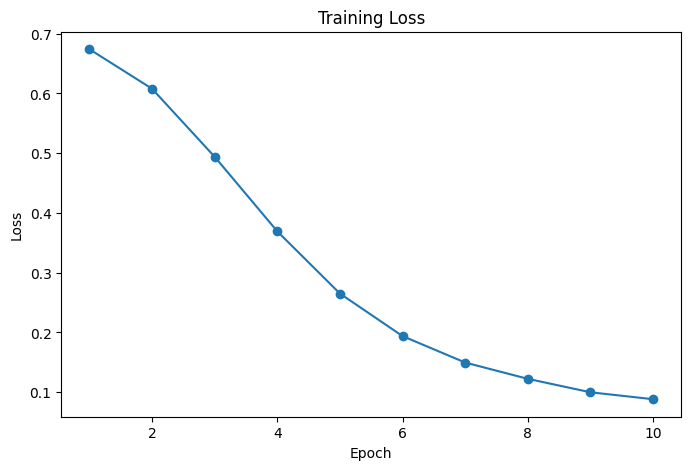

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

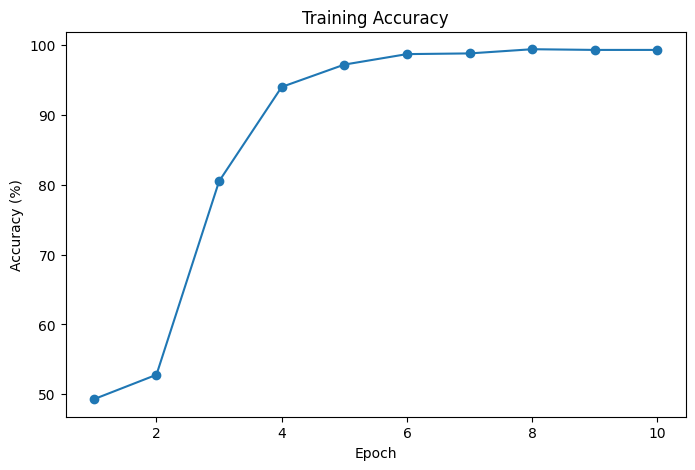

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    accuracy_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.show()

In [23]:
model.eval()

sample = torch.tensor([
    [2.0, 1.0]
])

with torch.no_grad():

    output = model(sample)

    prediction = torch.argmax(output, dim=1)

print("Input:", sample)
print("Predicted class:", prediction.item())

Input: tensor([[2., 1.]])
Predicted class: 1


In [24]:
torch.save(
    model.state_dict(),
    "simple_neural_network.pth"
)

print("Model saved successfully.")

Model saved successfully.


In [25]:
loaded_model = SimpleNeuralNetwork()

loaded_model.load_state_dict(
    torch.load(
        "simple_neural_network.pth",
        weights_only=True
    )
)

loaded_model.eval()

print("Model loaded successfully.")

Model loaded successfully.


# 6. Conclusion

This notebook demonstrated the fundamental workflow of building a neural network using PyTorch.

The project covered:

- PyTorch tensors
- Dataset and DataLoader
- Neural network construction using `nn.Module`
- Forward propagation
- Loss calculation
- Backpropagation
- Optimization using Adam
- Model training
- Model evaluation
- Prediction
- Saving and loading a trained model

This provides the fundamental PyTorch workflow used in the CNN and Feed-Forward Neural Network projects developed during Week 2.